## Importing libraries

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV

## Loading datasets

In [3]:
df_train = pd.read_csv('gold_extraction_prediction_datasets/gold_recovery_train.csv')
df_test = pd.read_csv('gold_extraction_prediction_datasets/gold_recovery_test.csv')
df_full = pd.read_csv('gold_extraction_prediction_datasets/gold_recovery_full.csv')

## Counting NaN values of gold rougher columns on df_train

In [4]:
print(df_train.columns[df_train.columns.str.contains('rougher')]) #Checking the columns that contain 'rougher' in their names
print()

print('NaN values in each column:') 
print('Feed: ', df_train['rougher.input.feed_au'].isna().sum())
print('Concentrate: ', df_train['rougher.output.concentrate_au'].isna().sum())
print('Tails: ', df_train['rougher.output.tail_au'].isna().sum())
print('Recovery original: ', df_train['rougher.output.recovery'].isna().sum())

Index(['rougher.calculation.sulfate_to_au_concentrate',
       'rougher.calculation.floatbank10_sulfate_to_au_feed',
       'rougher.calculation.floatbank11_sulfate_to_au_feed',
       'rougher.calculation.au_pb_ratio', 'rougher.input.feed_ag',
       'rougher.input.feed_pb', 'rougher.input.feed_rate',
       'rougher.input.feed_size', 'rougher.input.feed_sol',
       'rougher.input.feed_au', 'rougher.input.floatbank10_sulfate',
       'rougher.input.floatbank10_xanthate',
       'rougher.input.floatbank11_sulfate',
       'rougher.input.floatbank11_xanthate', 'rougher.output.concentrate_ag',
       'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol',
       'rougher.output.concentrate_au', 'rougher.output.recovery',
       'rougher.output.tail_ag', 'rougher.output.tail_pb',
       'rougher.output.tail_sol', 'rougher.output.tail_au',
       'rougher.state.floatbank10_a_air', 'rougher.state.floatbank10_a_level',
       'rougher.state.floatbank10_b_air', 'rougher.state.floa

## Validation of the recovery calculation

In [5]:
df_clean_train = df_train[['rougher.input.feed_au', 'rougher.output.concentrate_au', 'rougher.output.tail_au', 'rougher.output.recovery']].dropna() #Drop rows with NaN values in the relevant columns

F = df_clean_train['rougher.input.feed_au'] #Feed
C = df_clean_train['rougher.output.concentrate_au'] #Concentrate
T = df_clean_train['rougher.output.tail_au'] #Tail

recovery_rougher = (C * (F - T)) / (F * (C - T)) * 100 #Calculate recovery using the formula: Recovery = (C * (F - T)) / (F * (C - T)) * 100

mae = mean_absolute_error(df_clean_train['rougher.output.recovery'], recovery_rougher)
print(f'Mean Absolute Error: ', mae)


Mean Absolute Error:  9.303415616264301e-15


## Analysis of the lacking features of the test set

In [6]:
missing_columns = [] #List to store columns that are in train but not in test
for column in list(df_train.columns):
    if column not in list(df_test.columns):
        missing_columns.append(column)

print(f'Columns that are in train, but not in test: {len(missing_columns)}')
print()
print(missing_columns)
print()

rougher_count = 0 #Counter for parameters of the 'rougher' stage
cleaner_count = 0 #Counter for parameters of the 'cleaner' stage
final_count = 0 #Counter for parameters of the 'final' stage

for column in missing_columns: #Check if the column name contains 'final', 'rougher', or 'cleaner' and increment the respective counter
    if 'final' in column:
        final_count += 1
    elif 'rougher' in column:
        rougher_count += 1
    elif 'cleaner' in column:
        cleaner_count += 1

print(f"Parameters of the 'final' stage: {final_count}")
print(f"Parameters of the 'rougher' stage: {rougher_count}")  
print(f"Parameters of the 'cleaner' stage: {cleaner_count}")
print(f"Total: {final_count + rougher_count + cleaner_count}")


Columns that are in train, but not in test: 34

['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'rougher.output.concentrate_au', 'rougher.output.recovery', 'rougher.output.tail_ag', 'rougher.output.tail_pb'

## Development of recommender function

In [7]:
def analyze_distribution(df, columns_with_missing):
    
    recommendations = {} #Initiate a dictionary to store the recommended imputation method for each column.
    
    for column in columns_with_missing:
        data = df[column].dropna() #Drop NaN values to analyze the distribution of the existing data.
        
        if len(data) == 0: #If there is no data to analyze, recommend 'No data' and continue to the next column. 
            recommendations[column] = 'No data'
            continue
            
        mean_val = data.mean() #Assign the mean value of the column to a variable.
        median_val = data.median() #Assign the median value of the column to a variable.
        skewness = stats.skew(data) #Calculate the skewness of the data to determine if it is symmetric or skewed.
        
        Q1 = data.quantile(0.25) #Calculate the first quartile (Q1) to determine the lower bound for outliers.
        Q3 = data.quantile(0.75) #Calculate the third quartile (Q3) to determine the upper bound for outliers.
        IQR = Q3 - Q1 #Calculate the interquartile range (IQR) to determine the spread of the middle 50% of the data.
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)] #Identify outliers using the IQR method.
        outlier_percentage = len(outliers) / len(data) * 100 #Calculate the percentage of outliers in the data to determine if it is significant.
        
        if abs(skewness) > 1 or outlier_percentage > 5: #Decide on the imputation method based on skewness and outlier percentage. If the data is highly skewed or has a significant percentage of outliers, recommend 'median'. Otherwise, recommend 'mean'.
            recommendations[column] = 'median'
        else:
            recommendations[column] = 'mean'
    
    return recommendations

## Usage of recommender function on df_train

In [8]:
missing_train = df_train.isnull().sum().sort_values(ascending=False) #Calculating missing values in the train set.

columns_with_missing_train = missing_train[missing_train > 0].index.tolist() #Identifying columns with missing values in the train set.

recommendations_train = analyze_distribution(df_train, columns_with_missing_train) #Usage of recommender function for the train set.

for column, method in recommendations_train.items(): #Loop on the columns with missing values in the test set to print the recommended imputation method and the count of missing values.
    missing_count = missing_train[column]
    print(f"{column}: {method} (NaN: {missing_count})")

df_train_imputed = df_train.copy() #Creating a copy of the train set to apply imputation without modifying the original data.

for column, method in recommendations_train.items(): #Loop on the columns with missing values in the test set to apply the recommended imputation method.
    if method == 'mean':
        fill_value = df_train[column].mean()
    elif method == 'median':
        fill_value = df_train[column].median()
    
    df_train_imputed[column] = df_train_imputed[column].fillna(fill_value)
    

rougher.output.recovery: median (NaN: 2573)
rougher.output.tail_ag: mean (NaN: 2250)
rougher.output.tail_sol: median (NaN: 2249)
rougher.output.tail_au: mean (NaN: 2249)
secondary_cleaner.output.tail_sol: mean (NaN: 1986)
rougher.input.floatbank11_xanthate: median (NaN: 1904)
final.output.recovery: median (NaN: 1521)
primary_cleaner.input.sulfate: mean (NaN: 1307)
primary_cleaner.input.depressant: mean (NaN: 1262)
rougher.calculation.au_pb_ratio: median (NaN: 1242)
rougher.input.floatbank10_sulfate: median (NaN: 1044)
primary_cleaner.input.xanthate: mean (NaN: 985)
primary_cleaner.output.concentrate_sol: mean (NaN: 636)
rougher.input.floatbank11_sulfate: median (NaN: 623)
rougher.state.floatbank10_e_air: median (NaN: 603)
rougher.input.feed_rate: median (NaN: 513)
rougher.input.feed_size: median (NaN: 417)
final.output.concentrate_sol: median (NaN: 370)
secondary_cleaner.state.floatbank2_a_air: median (NaN: 363)
primary_cleaner.output.concentrate_pb: median (NaN: 358)
rougher.input.flo

## Uusage of recommender function on df_test

In [9]:
missing_test = df_test.isnull().sum().sort_values(ascending=False) #Calculating missing values in the test set.

columns_with_missing_test = missing_test[missing_test > 0].index.tolist() #Identifying columns with missing values in the test set.

recommendations_test = analyze_distribution(df_test, columns_with_missing_test) #Usage of recommender function for the test set.

for column, method in recommendations_test.items(): #Loop on the columns with missing values in the test set to print the recommended imputation method and the count of missing values.
    missing_count = missing_test[column]
    print(f"{column}: {method} (NaN: {missing_count})")

df_test_imputed = df_test.copy() #Creating a copy of the test set to apply imputation without modifying the original data.

for column, method in recommendations_test.items(): #Loop on the columns with missing values in the test set to apply the recommended imputation method.
    if method == 'mean':
        fill_value = df_test[column].mean()
    elif method == 'median':
        fill_value = df_test[column].median()
    
    df_test_imputed[column] = df_test_imputed[column].fillna(fill_value)
    

rougher.input.floatbank11_xanthate: median (NaN: 353)
primary_cleaner.input.sulfate: mean (NaN: 302)
primary_cleaner.input.depressant: mean (NaN: 284)
rougher.input.floatbank10_sulfate: median (NaN: 257)
primary_cleaner.input.xanthate: mean (NaN: 166)
rougher.input.floatbank10_xanthate: median (NaN: 123)
rougher.input.feed_sol: median (NaN: 67)
rougher.input.floatbank11_sulfate: median (NaN: 55)
rougher.input.feed_rate: median (NaN: 40)
secondary_cleaner.state.floatbank3_a_air: median (NaN: 34)
secondary_cleaner.state.floatbank2_b_air: median (NaN: 23)
rougher.input.feed_size: median (NaN: 22)
secondary_cleaner.state.floatbank2_a_air: median (NaN: 20)
rougher.state.floatbank10_a_air: median (NaN: 17)
rougher.state.floatbank10_c_air: median (NaN: 17)
rougher.state.floatbank10_d_air: median (NaN: 17)
rougher.state.floatbank10_e_air: median (NaN: 17)
rougher.state.floatbank10_b_air: median (NaN: 17)
rougher.state.floatbank10_f_air: median (NaN: 17)
secondary_cleaner.state.floatbank3_a_lev

## Verification of lack of missing values

In [10]:
print("Missing values after imputation:")
print("Train:", df_train_imputed.isnull().sum().sum())
print("Test:", df_test_imputed.isnull().sum().sum())

Missing values after imputation:
Train: 0
Test: 0


## Dropping the column 'date' because it is not useful for the analysis

In [11]:
df_train_imputed = df_train_imputed.drop('date', axis=1)
df_test_imputed = df_test_imputed.drop('date', axis=1)

## Printing all columns that have 'au' in them to select them later

In [12]:
print(df_train_imputed.columns[df_train_imputed.columns.str.contains('au')])

Index(['final.output.concentrate_au', 'final.output.tail_au',
       'primary_cleaner.output.concentrate_au',
       'primary_cleaner.output.tail_au',
       'rougher.calculation.sulfate_to_au_concentrate',
       'rougher.calculation.floatbank10_sulfate_to_au_feed',
       'rougher.calculation.floatbank11_sulfate_to_au_feed',
       'rougher.calculation.au_pb_ratio', 'rougher.input.feed_au',
       'rougher.output.concentrate_au', 'rougher.output.tail_au',
       'secondary_cleaner.output.tail_au'],
      dtype='str')


## Gold concentration changes through its purification

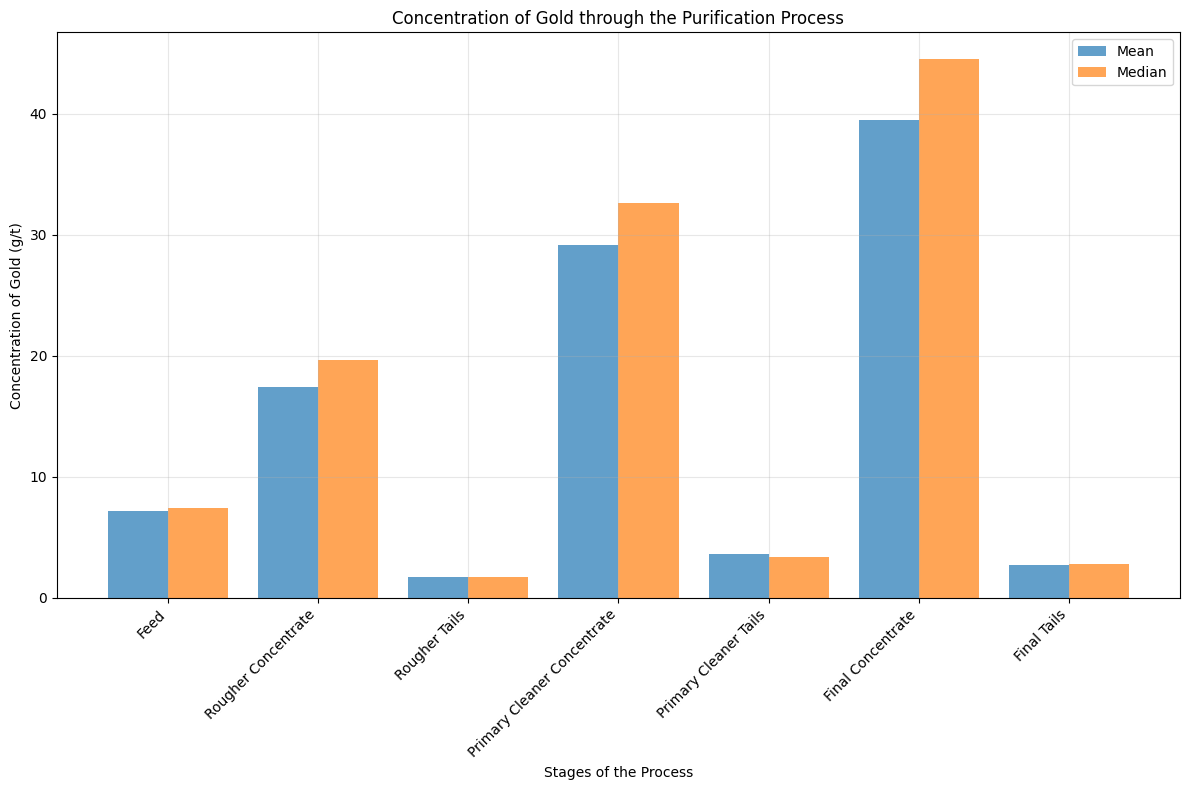

Average concentrations of gold by stage:
Feed: Mean = 7.17 g/t, Median = 7.44 g/t
Rougher Concentrate: Mean = 17.41 g/t, Median = 19.64 g/t
Rougher Tails: Mean = 1.76 g/t, Median = 1.76 g/t
Primary Cleaner Concentrate: Mean = 29.18 g/t, Median = 32.65 g/t
Primary Cleaner Tails: Mean = 3.59 g/t, Median = 3.40 g/t
Final Concentrate: Mean = 39.49 g/t, Median = 44.50 g/t
Final Tails: Mean = 2.69 g/t, Median = 2.78 g/t


In [13]:

gold_stages = { #Selecting only the relevant columns for gold.
    'Feed': 'rougher.input.feed_au',
    'Rougher Concentrate': 'rougher.output.concentrate_au', 
    'Rougher Tails': 'rougher.output.tail_au',
    'Primary Cleaner Concentrate': 'primary_cleaner.output.concentrate_au',
    'Primary Cleaner Tails': 'primary_cleaner.output.tail_au',
    'Final Concentrate': 'final.output.concentrate_au',
    'Final Tails': 'final.output.tail_au'
}

plt.figure(figsize=(12, 8)) #Creating a bar chart to compare the mean and median concentrations of gold at each stage of the process.

stages = []
means = []
medians = []

for stage_name, column in gold_stages.items(): #Loop through the selected gold-related columns to calculate mean and median values for the imputed train set.
    if column in df_train_imputed.columns:
        data = df_train_imputed[column].dropna()
        if len(data) > 0:
            stages.append(stage_name)
            means.append(data.mean())
            medians.append(data.median())

x_pos = range(len(stages))
plt.bar([x - 0.2 for x in x_pos], means, width=0.4, label='Mean', alpha=0.7)
plt.bar([x + 0.2 for x in x_pos], medians, width=0.4, label='Median', alpha=0.7)

plt.xlabel('Stages of the Process')
plt.ylabel('Concentration of Gold (g/t)')
plt.title('Concentration of Gold through the Purification Process')
plt.xticks(x_pos, stages, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average concentrations of gold by stage:") #Printing the average concentrations of gold by stage to compare the mean and median values.
for i, stage in enumerate(stages):
    print(f"{stage}: Mean = {means[i]:.2f} g/t, Median = {medians[i]:.2f} g/t")




## Printing all columns that have 'ag' in them to select them later

In [14]:
print(df_train_imputed.columns[df_train_imputed.columns.str.contains('ag')])

Index(['final.output.concentrate_ag', 'final.output.tail_ag',
       'primary_cleaner.output.concentrate_ag',
       'primary_cleaner.output.tail_ag', 'rougher.input.feed_ag',
       'rougher.output.concentrate_ag', 'rougher.output.tail_ag',
       'secondary_cleaner.output.tail_ag'],
      dtype='str')


## Silver concentration changes through its purification

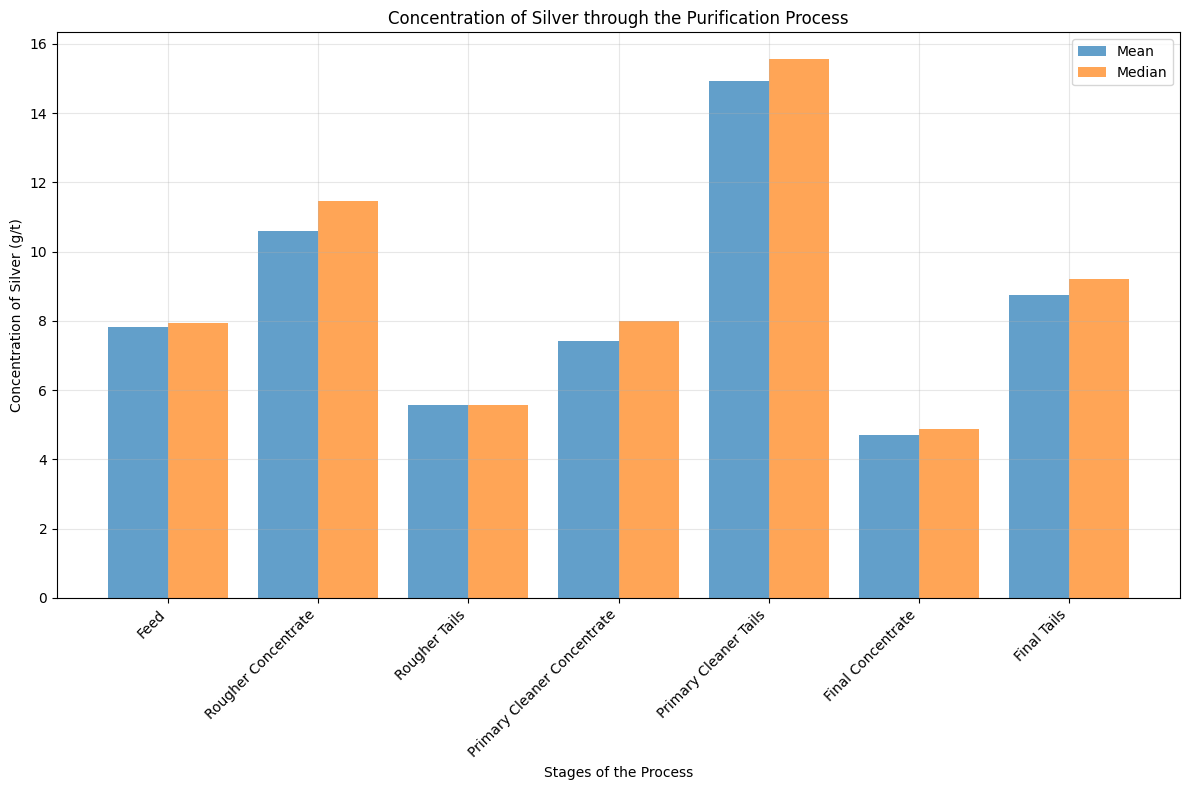

Average concentrations of silver by stage:
Feed: Mean = 7.83 g/t, Median = 7.94 g/t
Rougher Concentrate: Mean = 10.58 g/t, Median = 11.46 g/t
Rougher Tails: Mean = 5.57 g/t, Median = 5.57 g/t
Primary Cleaner Concentrate: Mean = 7.43 g/t, Median = 8.00 g/t
Primary Cleaner Tails: Mean = 14.92 g/t, Median = 15.55 g/t
Final Concentrate: Mean = 4.72 g/t, Median = 4.87 g/t
Final Tails: Mean = 8.76 g/t, Median = 9.22 g/t


In [15]:
silver_stages = { #Selecting only the relevant columns for silver.
    'Feed': 'rougher.input.feed_ag',
    'Rougher Concentrate': 'rougher.output.concentrate_ag',
    'Rougher Tails': 'rougher.output.tail_ag',
    'Primary Cleaner Concentrate': 'primary_cleaner.output.concentrate_ag',
    'Primary Cleaner Tails': 'primary_cleaner.output.tail_ag',
    'Final Concentrate': 'final.output.concentrate_ag',
    'Final Tails': 'final.output.tail_ag'
}

plt.figure(figsize=(12, 8)) #Creating a bar chart to compare the mean and median concentrations of silver at each stage of the process.

stages = []
means = []
medians = []

for stage_name, column in silver_stages.items(): #Loop through the selected silver-related columns to calculate mean and median values for the imputed train set.
    if column in df_train_imputed.columns:
        data = df_train_imputed[column].dropna()
        if len(data) > 0:
            stages.append(stage_name)
            means.append(data.mean())
            medians.append(data.median())

x_pos = range(len(stages))
plt.bar([x - 0.2 for x in x_pos], means, width=0.4, label='Mean', alpha=0.7)
plt.bar([x + 0.2 for x in x_pos], medians, width=0.4, label='Median', alpha=0.7)

plt.xlabel('Stages of the Process')
plt.ylabel('Concentration of Silver (g/t)')
plt.title('Concentration of Silver through the Purification Process')
plt.xticks(x_pos, stages, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average concentrations of silver by stage:") #Printing the average concentrations of silver by stage to compare the mean and median values.
for i, stage in enumerate(stages):
    print(f"{stage}: Mean = {means[i]:.2f} g/t, Median = {medians[i]:.2f} g/t")


## Printing all columns that have 'pb' in them to select them later

In [16]:
print(df_train_imputed.columns[df_train_imputed.columns.str.contains('pb')])

Index(['final.output.concentrate_pb', 'final.output.tail_pb',
       'primary_cleaner.output.concentrate_pb',
       'primary_cleaner.output.tail_pb', 'rougher.calculation.au_pb_ratio',
       'rougher.input.feed_pb', 'rougher.output.concentrate_pb',
       'rougher.output.tail_pb', 'secondary_cleaner.output.tail_pb'],
      dtype='str')


## Lead concentration changes through its purification

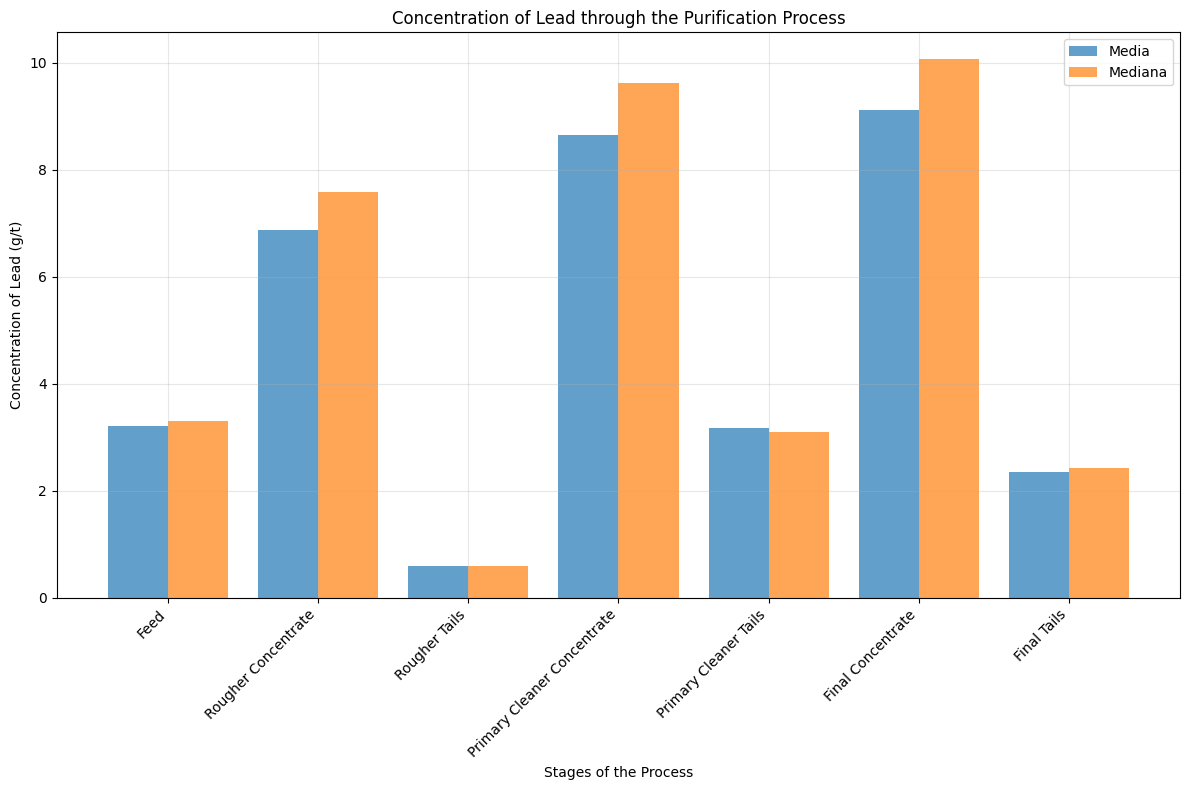

Average concentrations of lead by stage:
Feed: Mean = 3.22 g/t, Median = 3.30 g/t
Rougher Concentrate: Mean = 6.88 g/t, Median = 7.58 g/t
Rougher Tails: Mean = 0.60 g/t, Median = 0.60 g/t
Primary Cleaner Concentrate: Mean = 8.64 g/t, Median = 9.62 g/t
Primary Cleaner Tails: Mean = 3.17 g/t, Median = 3.10 g/t
Final Concentrate: Mean = 9.12 g/t, Median = 10.07 g/t
Final Tails: Mean = 2.36 g/t, Median = 2.44 g/t


In [17]:
lead_stages = { #Selecting only the relevant columns for lead.
    'Feed': 'rougher.input.feed_pb',
    'Rougher Concentrate': 'rougher.output.concentrate_pb',
    'Rougher Tails': 'rougher.output.tail_pb',
    'Primary Cleaner Concentrate': 'primary_cleaner.output.concentrate_pb',
    'Primary Cleaner Tails': 'primary_cleaner.output.tail_pb',
    'Final Concentrate': 'final.output.concentrate_pb',
    'Final Tails': 'final.output.tail_pb'
}

plt.figure(figsize=(12, 8)) #Creating a bar chart to compare the mean and median concentrations of lead at each stage of the process.

stages = []
means = []
medians = []

for stage_name, column in lead_stages.items(): #Loop through the selected lead-related columns to calculate mean and median values for the imputed train set.
    if column in df_train_imputed.columns:
        data = df_train_imputed[column].dropna()
        if len(data) > 0:
            stages.append(stage_name)
            means.append(data.mean())
            medians.append(data.median())

x_pos = range(len(stages))
plt.bar([x - 0.2 for x in x_pos], means, width=0.4, label='Media', alpha=0.7)
plt.bar([x + 0.2 for x in x_pos], medians, width=0.4, label='Mediana', alpha=0.7)

plt.xlabel('Stages of the Process')
plt.ylabel('Concentration of Lead (g/t)')
plt.title('Concentration of Lead through the Purification Process')
plt.xticks(x_pos, stages, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average concentrations of lead by stage:") #Printing the average concentrations of lead by stage to compare the mean and median values.
for i, stage in enumerate(stages):
    print(f"{stage}: Mean = {means[i]:.2f} g/t, Median = {medians[i]:.2f} g/t")


## Printing all columns that have 'feed_size' in them to use them later

In [18]:
print(df_train_imputed.columns[df_train_imputed.columns.str.contains('feed_size')])
print(df_test_imputed.columns[df_test_imputed.columns.str.contains('feed_size')])


Index(['primary_cleaner.input.feed_size', 'rougher.input.feed_size'], dtype='str')
Index(['primary_cleaner.input.feed_size', 'rougher.input.feed_size'], dtype='str')


## Plotting distributions of particle sizes to verify that theyre roughly the same

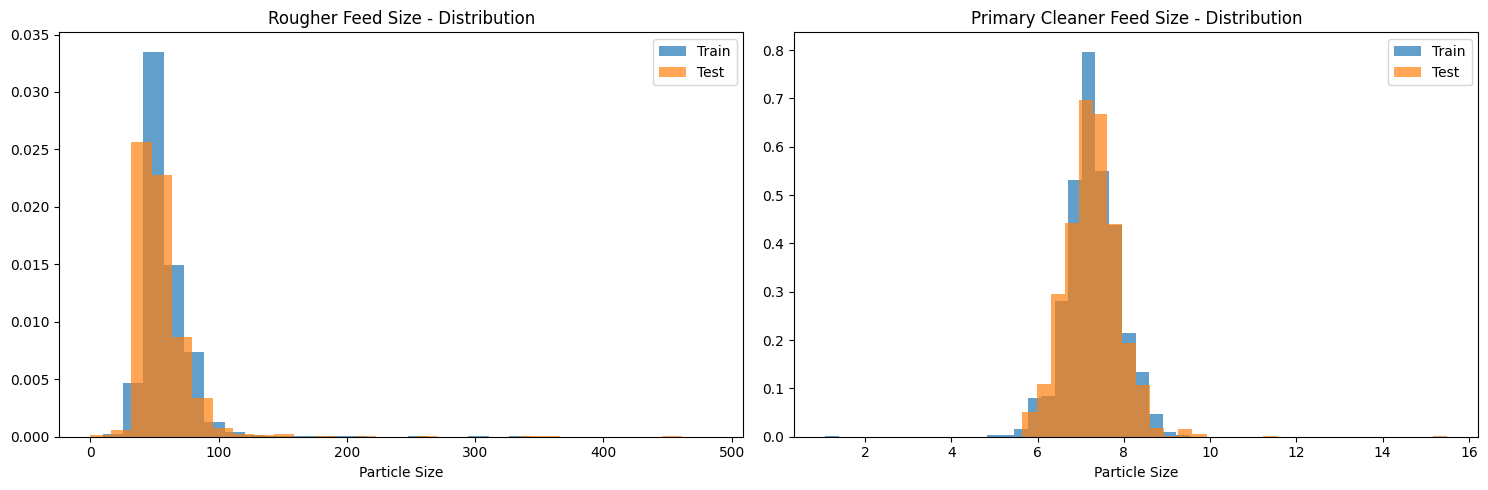

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_train_imputed['rougher.input.feed_size'], bins=30, alpha=0.7, label='Train', density=True)
axes[0].hist(df_test_imputed['rougher.input.feed_size'], bins=30, alpha=0.7, label='Test', density=True)
axes[0].set_title('Rougher Feed Size - Distribution')
axes[0].set_xlabel('Particle Size')
axes[0].legend()

axes[1].hist(df_train_imputed['primary_cleaner.input.feed_size'], bins=30, alpha=0.7, label='Train', density=True)
axes[1].hist(df_test_imputed['primary_cleaner.input.feed_size'], bins=30, alpha=0.7, label='Test', density=True)
axes[1].set_title('Primary Cleaner Feed Size - Distribution')
axes[1].set_xlabel('Particle Size')
axes[1].legend()

plt.tight_layout()
plt.show()


Particle sizes are similar in both datasets, so it is likely that the model's assessment will be correct.

## Printing all colmuns that have 'au', 'ag' or 'pb' in the train dataset to use later

In [20]:

print(df_train_imputed.columns[df_train_imputed.columns.str.contains('au')])
print()
print(df_train_imputed.columns[df_train_imputed.columns.str.contains('ag')])
print()
print(df_train_imputed.columns[df_train_imputed.columns.str.contains('pb')])


Index(['final.output.concentrate_au', 'final.output.tail_au',
       'primary_cleaner.output.concentrate_au',
       'primary_cleaner.output.tail_au',
       'rougher.calculation.sulfate_to_au_concentrate',
       'rougher.calculation.floatbank10_sulfate_to_au_feed',
       'rougher.calculation.floatbank11_sulfate_to_au_feed',
       'rougher.calculation.au_pb_ratio', 'rougher.input.feed_au',
       'rougher.output.concentrate_au', 'rougher.output.tail_au',
       'secondary_cleaner.output.tail_au'],
      dtype='str')

Index(['final.output.concentrate_ag', 'final.output.tail_ag',
       'primary_cleaner.output.concentrate_ag',
       'primary_cleaner.output.tail_ag', 'rougher.input.feed_ag',
       'rougher.output.concentrate_ag', 'rougher.output.tail_ag',
       'secondary_cleaner.output.tail_ag'],
      dtype='str')

Index(['final.output.concentrate_pb', 'final.output.tail_pb',
       'primary_cleaner.output.concentrate_pb',
       'primary_cleaner.output.tail_pb', 'rougher.calculat

## Adding 'au', 'ag' and 'pb' into total_feed, total_rougher and total_final

In [21]:

total_feed = df_train_imputed['rougher.input.feed_au'] + df_train_imputed['rougher.input.feed_ag'] + df_train_imputed['rougher.input.feed_pb']
total_rougher = df_train_imputed['rougher.output.concentrate_au'] + df_train_imputed['rougher.output.concentrate_ag'] + df_train_imputed['rougher.output.concentrate_pb']
total_final = df_train_imputed['final.output.concentrate_au'] + df_train_imputed['final.output.concentrate_ag'] + df_train_imputed['final.output.concentrate_pb']



## Distribution analysis and partial outlier elimination on total_feed

Descriptive statistics of total_feed:
count    16860.000000
mean        18.224909
std          7.304109
min          0.000000
25%         16.139539
50%         18.709881
75%         22.327806
max         35.071987
dtype: float64


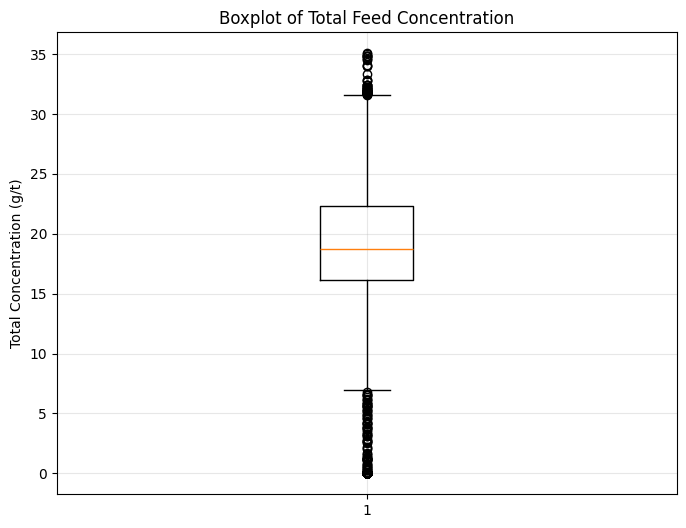

Percentage of outliers:  9.881376037959667

Analysis of outliers
Total outliers: 1666 (9.88%)
Normal range: 6.86 to 31.61

Statistics of outliers:
count    1666.000000
mean        1.341860
std         6.092900
min         0.000000
25%         0.000000
50%         0.000000
75%         0.030000
max        35.071987
dtype: float64

Lower outliers: 1606
Upper outliers: 60

Most extreme outliers:
5 lowest:  [0. 0. 0. 0. 0.]
5 highest:  [35.07198663 34.976709   34.83723054 34.83021975 34.82168125]

Original data: 16860
Data after cleaning: 15701
Data removed: 1159
Percentage removed: 6.87%

New statistics:
count    15701.000000
mean        19.570216
std          5.564059
min          0.030000
25%         16.691622
50%         19.103816
75%         22.699182
max         35.071987
dtype: float64


In [22]:
print("Descriptive statistics of total_feed:")
print(total_feed.describe())

plt.figure(figsize=(8, 6))
plt.boxplot(total_feed)
plt.title('Boxplot of Total Feed Concentration')
plt.ylabel('Total Concentration (g/t)')
plt.grid(True, alpha=0.3)
plt.show()

Q1_feed = total_feed.quantile(0.25) #Calculate the first quartile (Q1) to determine the lower bound for outliers in the total_feed concentration.
Q3_feed = total_feed.quantile(0.75) #Calculate the third quartile (Q3) to determine the upper bound for outliers in the total_feed concentration.
IQR_feed = Q3_feed - Q1_feed #Calculate the interquartile range (IQR) to determine the spread of the middle 50% of the data in the total_feed concentration.

inferior_limit_feed = Q1_feed - 1.5 * IQR_feed #Calculate the lower limit for outliers in the total_feed concentration using the IQR method, which identifies data points that are significantly lower than the rest of the data.
superior_limit_feed = Q3_feed + 1.5 * IQR_feed #Calculate the upper limit for outliers in the total_feed concentration using the IQR method, which identifies data points that are significantly higher than the rest of the data.

outliers_feed = total_feed[(total_feed < inferior_limit_feed) | (total_feed > superior_limit_feed)] #Identify outliers in the total_feed concentration using the IQR method to determine which data points are significantly different from the rest of the data.

outliers_percentage_feed = (len(outliers_feed) / len(total_feed)) * 100 #Calculate the percentage of outliers in the total_feed concentration to determine if it is significant.

print('Percentage of outliers: ', outliers_percentage_feed)
print()

print("Analysis of outliers")
print(f"Total outliers: {len(outliers_feed)} ({outliers_percentage_feed:.2f}%)")
print(f"Normal range: {inferior_limit_feed:.2f} to {superior_limit_feed:.2f}")
print()

print("Statistics of outliers:")
print(outliers_feed.describe())
print()

low_outliers_feed = outliers_feed[outliers_feed < inferior_limit_feed]
high_outliers_feed = outliers_feed[outliers_feed > superior_limit_feed]
print(f"Lower outliers: {len(low_outliers_feed)}")
print(f"Upper outliers: {len(high_outliers_feed)}")
print()

print("Most extreme outliers:")
print("5 lowest: ", outliers_feed.nsmallest(5).values)
print("5 highest: ", outliers_feed.nlargest(5).values)
print()

total_feed_clean = total_feed[total_feed > 0] #Filter out negative values and zero values from the total feed concentration, as they are not physically meaningful in this context and could skew the analysis.

print(f"Original data: {len(total_feed)}")
print(f"Data after cleaning: {len(total_feed_clean)}")
print(f"Data removed: {len(total_feed) - len(total_feed_clean)}")
print(f"Percentage removed: {((len(total_feed) - len(total_feed_clean)) / len(total_feed)) * 100:.2f}%")
print()

print("New statistics:")
print(total_feed_clean.describe())


## Distribution analysis and partial outlier elimination on total_rougher

Descriptive statistics of total_rougher:
count    16860.000000
mean        34.880945
std         13.534712
min          0.000000
25%         36.710078
50%         39.451745
75%         41.625835
max         55.568687
dtype: float64


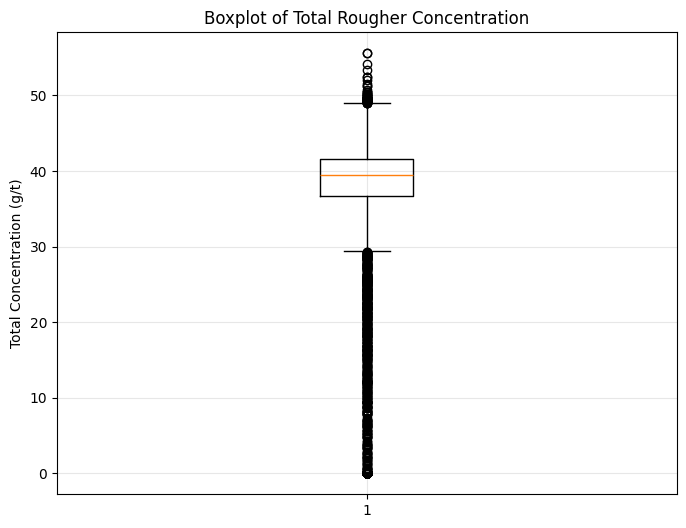

Percentage of outliers:  14.73902728351127

Analysis of outliers
Total outliers: 2485 (14.74%)
Normal range: 29.34 to 49.00

Statistics of outliers:
count    2485.000000
mean        4.571781
std        10.360834
min         0.000000
25%         0.000000
50%         0.000000
75%         0.030000
max        55.568687
dtype: float64

Lower outliers: 2431
Upper outliers: 54

Most extreme outliers:
5 lowest:  [0. 0. 0. 0. 0.]
5 highest:  [55.56868746 55.54522147 54.0851951  53.31678675 52.41644075]

Original data: 16860
Data after cleaning: 15367
Data removed: 1493
Percentage removed: 8.86%

New statistics:
count    15367.000000
mean        38.269847
std          8.443121
min          0.029924
25%         37.767557
50%         39.808841
75%         41.872496
max         55.568687
dtype: float64


In [23]:
print("Descriptive statistics of total_rougher:")
print(total_rougher.describe())

plt.figure(figsize=(8, 6))
plt.boxplot(total_rougher)
plt.title('Boxplot of Total Rougher Concentration')
plt.ylabel('Total Concentration (g/t)')
plt.grid(True, alpha=0.3)
plt.show()

Q1_rougher = total_rougher.quantile(0.25) #Calculate the first quartile (Q1) to determine the lower bound for outliers in the total_rougher concentration.
Q3_rougher = total_rougher.quantile(0.75) #Calculate the third quartile (Q3) to determine the upper bound for outliers in the total_rougher concentration.
IQR_rougher = Q3_rougher - Q1_rougher #Calculate the interquartile range (IQR) to determine the spread of the middle 50% of the data in the total_rougher concentration.

inferior_limit_rougher = Q1_rougher - 1.5 * IQR_rougher #Calculate the lower limit for outliers in the total_rougher concentration using the IQR method, which identifies data points that are significantly lower than the rest of the data.
superior_limit_rougher = Q3_rougher + 1.5 * IQR_rougher #Calculate the upper limit for outliers in the total_rougher concentration using the IQR method, which identifies data points that are significantly higher than the rest of the data.

outliers_rougher = total_rougher[(total_rougher < inferior_limit_rougher) | (total_rougher > superior_limit_rougher)] #Identify outliers in the total_rougher concentration using the IQR method to determine which data points are significantly different from the rest of the data.

outliers_percentage_rougher = (len(outliers_rougher) / len(total_rougher)) * 100 #Calculate the percentage of outliers in the total_rougher concentration to determine if it is significant.

print('Percentage of outliers: ', outliers_percentage_rougher)
print()

print("Analysis of outliers")
print(f"Total outliers: {len(outliers_rougher)} ({outliers_percentage_rougher:.2f}%)")
print(f"Normal range: {inferior_limit_rougher:.2f} to {superior_limit_rougher:.2f}")
print()

print("Statistics of outliers:")
print(outliers_rougher.describe())
print()

low_outliers_rougher = outliers_rougher[outliers_rougher < inferior_limit_rougher]
high_outliers_rougher = outliers_rougher[outliers_rougher > superior_limit_rougher]
print(f"Lower outliers: {len(low_outliers_rougher)}")
print(f"Upper outliers: {len(high_outliers_rougher)}")
print()

print("Most extreme outliers:")
print("5 lowest: ", outliers_rougher.nsmallest(5).values)
print("5 highest: ", outliers_rougher.nlargest(5).values)
print()

total_rougher_clean = total_rougher[total_rougher > 0] #Filter out negative values and zero values from the total rougher concentration, as they are not physically meaningful in this context and could skew the analysis.

print(f"Original data: {len(total_rougher)}")
print(f"Data after cleaning: {len(total_rougher_clean)}")
print(f"Data removed: {len(total_rougher) - len(total_rougher_clean)}")
print(f"Percentage removed: {((len(total_rougher) - len(total_rougher_clean)) / len(total_rougher)) * 100:.2f}%")
print()

print("New statistics:")
print(total_rougher_clean.describe())



## Distribution analysis and partial outlier elimination on total_final

Descriptive statistics of total_final:
count    16860.000000
mean        53.323588
std         18.410424
min          0.000000
25%         58.560117
50%         59.983773
75%         60.934461
max         65.575259
dtype: float64


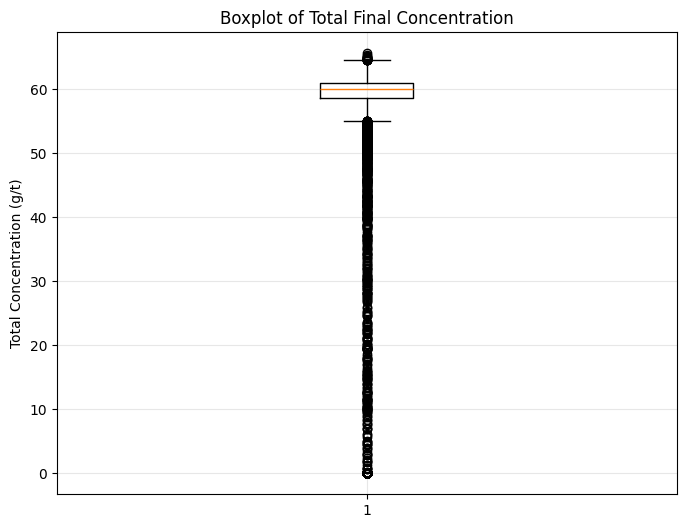

Percentage of outliers:  14.22894424673784

Analysis of outliers
Total outliers: 2399 (14.23%)
Normal range: 55.00 to 64.50

Descriptive statistics of outliers:
count    2399.000000
mean       12.476407
std        20.619204
min         0.000000
25%         0.000000
50%         0.000000
75%        23.370095
max        65.575259
dtype: float64

Lower outliers: 2380
Upper outliers: 19

Most extreme outliers:
5 lowest:  [0. 0. 0. 0. 0.]
5 highest:  [65.5752586  65.29110297 65.16285869 64.96888116 64.93891348]

Original data: 16860
Data after cleaning: 15597
Data removed: 1263
Percentage removed: 7.49%

New statistics:
count    15597.000000
mean        57.641578
std         10.838838
min          0.030000
25%         58.998996
50%         60.151216
75%         61.006870
max         65.575259
dtype: float64


In [24]:
print("Descriptive statistics of total_final:")
print(total_final.describe())

plt.figure(figsize=(8, 6))
plt.boxplot(total_final)
plt.title('Boxplot of Total Final Concentration')
plt.ylabel('Total Concentration (g/t)')
plt.grid(True, alpha=0.3)
plt.show()

Q1_final = total_final.quantile(0.25) #Calculate the first quartile (Q1) to determine the lower bound for outliers in the total_final concentration.
Q3_final = total_final.quantile(0.75) #Calculate the third quartile (Q3) to determine the upper bound for outliers in the total_final concentration.
IQR_final = Q3_final - Q1_final #Calculate the interquartile range (IQR) to determine the spread of the middle 50% of the data in the total_final concentration.

inferior_limit_final = Q1_final - 1.5 * IQR_final #Calculate the lower limit for outliers in the total_final concentration using the IQR method, which identifies data points that are significantly lower than the rest of the data.
superior_limit_final = Q3_final + 1.5 * IQR_final #Calculate the upper limit for outliers in the total_final concentration using the IQR method, which identifies data points that are significantly higher than the rest of the data.

outliers_final = total_final[(total_final < inferior_limit_final) | (total_final > superior_limit_final)] #Identify outliers in the total_final concentration using the IQR method to determine which data points are significantly different from the rest of the data.

outliers_percentage_final = (len(outliers_final) / len(total_final)) * 100 #Calculate the percentage of outliers in the total_final concentration to determine if it is significant.

print('Percentage of outliers: ', outliers_percentage_final)
print()

print("Analysis of outliers")
print(f"Total outliers: {len(outliers_final)} ({outliers_percentage_final:.2f}%)")
print(f"Normal range: {inferior_limit_final:.2f} to {superior_limit_final:.2f}")
print()

print("Descriptive statistics of outliers:")
print(outliers_final.describe())
print()

low_outliers_final = outliers_final[outliers_final < inferior_limit_final]
high_outliers_final = outliers_final[outliers_final > superior_limit_final]
print(f"Lower outliers: {len(low_outliers_final)}")
print(f"Upper outliers: {len(high_outliers_final)}")
print()

print("Most extreme outliers:")
print("5 lowest: ", outliers_final.nsmallest(5).values)
print("5 highest: ", outliers_final.nlargest(5).values)
print()

total_final_clean = total_final[total_final > 0] #Filter out negative values and zero values from the total final concentration, as they are not physically meaningful in this context and could skew the analysis.

print(f"Original data: {len(total_final)}")
print(f"Data after cleaning: {len(total_final_clean)}")
print(f"Data removed: {len(total_final) - len(total_final_clean)}")
print(f"Percentage removed: {((len(total_final) - len(total_final_clean)) / len(total_final)) * 100:.2f}%")
print()

print("New statistics:")
print(total_final_clean.describe())



## Adding together total_feed, total_rougher and total_final with values greater than zero only

In [25]:
df_train_clean = df_train_imputed[(total_feed > 0) & (total_rougher > 0) & (total_final > 0)]


## Searching for all columns with 'au', 'ag' and 'pb' in the test dataset to use later

In [26]:
print(df_test_imputed.columns[df_test_imputed.columns.str.contains('au')])
print()
print(df_test_imputed.columns[df_test_imputed.columns.str.contains('ag')])
print()
print(df_test_imputed.columns[df_test_imputed.columns.str.contains('pb')])


Index(['rougher.input.feed_au'], dtype='str')

Index(['rougher.input.feed_ag'], dtype='str')

Index(['rougher.input.feed_pb'], dtype='str')


## Adding together all the 'feed' columns from the test dataset

In [27]:
total_feed_test = df_test_imputed['rougher.input.feed_au'] + df_test_imputed['rougher.input.feed_ag'] + df_test_imputed['rougher.input.feed_pb']

## Filtering out all the values equal to or lower than zero in the test dataset

In [28]:
df_test_clean = df_test_imputed[total_feed_test > 0]


## A sMAPE function that was requested, but that is not used in the exercise

In [29]:
def smape_final(y_true_1, y_pred_1, y_true_2, y_pred_2):
    numerator_1 = abs(y_true_1 - y_pred_1)
    denominator_1 = (abs(y_true_1) + abs(y_pred_1)) / 2
    result_1 = (numerator_1 / denominator_1).mean() * 100
    numerator_2 = abs(y_true_2 - y_pred_2)
    denominator_2 = (abs(y_true_2) + abs(y_pred_2)) / 2
    result_2 = (numerator_2 / denominator_2).mean() * 100
    final_result = 0.25 * result_1 + 0.75 * result_2
    return final_result

## Dropping columns from df_train_clean to match df_test_clean

In [30]:
print("Columns in df_train_clean:", df_train_clean.columns.tolist())
print()
print("Columns in missing_columns:", missing_columns)
print()
columns_to_drop = [col for col in missing_columns if col in df_train_clean.columns] #Identify columns to drop from df_train_clean based on the missing_columns list, ensuring that only columns that are present in df_train_clean are included in the drop list.
df_train_short = df_train_clean.drop(columns=columns_to_drop) #Drop the identified columns from df_train_clean to create df_train_short, which will be used for further analysis or modeling while ensuring that only relevant columns are retained.
print(df_train_short.columns == df_test_clean.columns) #Verify that datasets have the same columns after dropping the identified columns from df_train_clean, ensuring that df_train_short and df_test_clean have the same structure for subsequent analysis or modeling.


Columns in df_train_clean: ['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au', 'primary_cleaner.input.sulfate', 'primary_cleaner.input.depressant', 'primary_cleaner.input.feed_size', 'primary_cleaner.input.xanthate', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au', 'primary_cleaner.state.floatbank8_a_air', 'primary_cleaner.state.floatbank8_a_level', 'primary_cleaner.state.floatbank8_b_air', 'primary_cleaner.state.floatbank8_b_level', 'primary_cleaner.state.floatbank8_c_air', 'primary_cleaner.state.floatbank8_c_level', 'primary_cleaner.state.floa

## Definition of features and target variables of the train dataset

In [31]:
print(df_test_imputed.columns[df_test_imputed.columns.str.contains('recovery')]) #Check for the presence of recovery columns in the test set to confirm that they are not included, as they are the target variables for prediction and should not be present in the test set to avoid data leakage.

target_rougher = df_train_clean['rougher.output.recovery'] #Assign the 'rougher.output.recovery' column from df_train_clean to the variable target_rougher, which will be used as the target variable for modeling or analysis related to the rougher stage of the process.
target_final = df_train_clean['final.output.recovery'] #Assign the 'final.output.recovery' column from df_train_clean to the variable target_final, which will be used as the target variable for modeling or analysis related to the final stage of the process.
features = df_train_short #Assign the remaining columns from df_train_short to the variable features, which will be used as the input variables for modeling or analysis.

print(f"Target rougher shape: {target_rougher.shape}")
print(f"Target final shape: {target_final.shape}")
print(f"Features shape: {features.shape}")

Index([], dtype='str')
Target rougher shape: (15178,)
Target final shape: (15178,)
Features shape: (15178, 52)


## Definition of sMAPE function

In [32]:
def smape_single(y_true, y_pred): #Define a function smape_single that calculates the Symmetric Mean Absolute Percentage Error (sMAPE) between the true values (y_true) and the predicted values (y_pred) for a single target variable, which will be used as a custom scoring function for model evaluation.
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100



## Definition of custom sMAPE scorer

In [33]:
smape_scorer = make_scorer(smape_single, greater_is_better=False)

## Using DecisionTreeRegressor on the train dataset

In [34]:
dt_regressor = DecisionTreeRegressor(random_state=12345) #Initialize a DecisionTreeRegressor with a fixed random state for reproducibility, which will be used as the model for predicting the target variables related to the rougher and final recovery stages of the process.

cv_scores_rougher_dt = cross_val_score(dt_regressor, features, target_rougher, cv=5, scoring=smape_scorer) #Perform cross-validation using the DecisionTreeRegressor to evaluate its performance in predicting the Rougher Recovery and Final Recovery target variables, using the custom sMAPE scorer for evaluation and specifying 5-fold cross-validation to obtain a distribution of performance scores across different subsets of the data.

print("Cross validation scores for Rougher Recovery:")
print(cv_scores_rougher_dt)
print(f"Mean sMAPE: {-cv_scores_rougher_dt.mean():.4f}")
print(f"Standard deviation: {cv_scores_rougher_dt.std():.4f}")
print()

cv_scores_final_dt = cross_val_score(dt_regressor, features, target_final, cv=5, scoring=smape_scorer)

print("Cross-validation scores for Final Recovery:")
print(cv_scores_final_dt)
print(f"Mean sMAPE: {-cv_scores_final_dt.mean():.4f}")
print(f"Standard deviation: {cv_scores_final_dt.std():.4f}")
print()

smape_final_dt = 0.25 * (-cv_scores_rougher_dt.mean()) + 0.75 * (-cv_scores_final_dt.mean()) #Define the final sMAPE score for the Decision Tree model by combining the mean sMAPE scores from both the Rougher Recovery and Final Recovery predictions, using a weighted average where the Final Recovery score is given more weight (75%) compared to the Rougher Recovery score (25%), to reflect the importance of accurately predicting the Final Recovery in the overall evaluation of the model's performance.

print(f"sMAPE final: {smape_final_dt:.4f}")


Cross validation scores for Rougher Recovery:
[-10.1779042   -8.89207396  -7.49808176  -8.73480826  -8.934205  ]
Mean sMAPE: 8.8474
Standard deviation: 0.8501

Cross-validation scores for Final Recovery:
[-19.4119815  -17.79281613 -17.47187546 -15.74263244 -20.50001013]
Mean sMAPE: 18.1839
Standard deviation: 1.6427

sMAPE final: 15.8498


## Using RandomForestRegressor on the train dataset

In [35]:
rf_regressor = RandomForestRegressor(random_state=12345) #Initialize a RandomForestRegressor with a fixed random state for reproducibility, which will be used as the model for predicting the target variables related to the rougher and final recovery stages of the process, allowing for an ensemble approach that combines multiple decision trees to improve predictive performance and reduce overfitting compared to a single decision tree model.

cv_scores_rougher_rf = cross_val_score(rf_regressor, features, target_rougher, cv=5, scoring=smape_scorer) #Perform cross-validation using the RandomForestRegressor to evaluate its performance in predicting the Rougher Recovery and Final Recovery target variables, using the custom sMAPE scorer for evaluation and specifying 5-fold cross-validation to obtain a distribution of performance scores across different subsets of the data, allowing for an assessment of the model's generalization ability and robustness in predicting the target variables related to the recovery stages of the process.

print("Cross validation scores for Rougher Recovery:")
print(cv_scores_rougher_rf)
print(f"Mean sMAPE: {-cv_scores_rougher_rf.mean():.4f}")
print(f"Standard deviation: {cv_scores_rougher_rf.std():.4f}")
print()

cv_scores_final_rf = cross_val_score(rf_regressor, features, target_final, cv=5, scoring=smape_scorer) #Perform cross-validation using the RandomForestRegressor to evaluate its performance in predicting the Final Recovery target variable, using the custom sMAPE scorer for evaluation and specifying 5-fold cross-validation to obtain a distribution of performance scores across different subsets of the data, allowing for an assessment of the model's generalization ability and robustness in predicting the Final Recovery, which is a critical aspect of the overall evaluation of the model's performance in the context of the gold recovery process.

print("Cross-validation scores for Final Recovery:")
print(cv_scores_final_rf)
print(f"Mean sMAPE: {-cv_scores_final_rf.mean():.4f}")
print(f"Standard deviation: {cv_scores_final_rf.std():.4f}")
print()

smape_final_rf = 0.25 * (-cv_scores_rougher_rf.mean()) + 0.75 * (-cv_scores_final_rf.mean()) #Define the final sMAPE score for the Random Forest model by combining the mean sMAPE scores from both the Rougher Recovery and Final Recovery predictions, using a weighted average where the Final Recovery score is given more weight (75%) compared to the Rougher Recovery score (25%), to reflect the importance of accurately predicting the Final Recovery in the overall evaluation of the model's performance, and to provide a single metric that summarizes the model's predictive accuracy across both target variables related to the recovery stages of the process.

print(f"sMAPE final: {smape_final_rf:.4f}")


Cross validation scores for Rougher Recovery:
[-7.70278979 -6.84069003 -5.62714215 -7.92162743 -9.23981722]
Mean sMAPE: 7.4664
Standard deviation: 1.1985

Cross-validation scores for Final Recovery:
[ -9.77882988  -9.78612887  -9.97842125  -9.10160678 -11.11446596]
Mean sMAPE: 9.9519
Standard deviation: 0.6531

sMAPE final: 9.3305


## Using LinearRegression on the train dataset

In [36]:
linear_regression = LinearRegression() #Initialize a LinearRegression model, which will be used as a baseline model for predicting the target variables related to the rougher and final recovery stages of the process, allowing for an assessment of the performance of a simple linear model in comparison to more complex models like Decision Tree and Random Forest, and providing insights into the linear relationships between the features and the target variables in the context of the gold recovery process.

cv_scores_rougher_linear = cross_val_score(linear_regression, features, target_rougher, cv=5, scoring=smape_scorer) #Perform cross-validation using the LinearRegression model to evaluate its performance in predicting the Rougher Recovery target variable, using the custom sMAPE scorer for evaluation and specifying 5-fold cross-validation to obtain a distribution of performance scores across different subsets of the data, allowing for an assessment of the model's generalization ability and robustness in predicting the Rougher Recovery, which is an important aspect of understanding the linear relationships between the features and the target variable in the context of the gold recovery process.

print("Cross-validation scores for Rougher Recovery:")
print(cv_scores_rougher_linear)
print(f"Mean sMAPE: {-cv_scores_rougher_linear.mean():.4f}")
print(f"Standard deviation: {cv_scores_rougher_linear.std():.4f}")
print()

cv_scores_final_linear = cross_val_score(linear_regression, features, target_final, cv=5, scoring=smape_scorer) #Perform cross-validation using the LinearRegression model to evaluate its performance in predicting the Final Recovery target variable, using the custom sMAPE scorer for evaluation and specifying 5-fold cross-validation to obtain a distribution of performance scores across different subsets of the data, allowing for an assessment of the model's generalization ability and robustness in predicting the Final Recovery, which is a critical aspect of understanding the linear relationships between the features and the target variable in the context of the gold recovery process.

print("Cross-validation scores for Final Recovery:")
print(cv_scores_final_linear)
print(f"Mean sMAPE: {-cv_scores_final_linear.mean():.4f}")
print(f"Standard deviation: {cv_scores_final_linear.std():.4f}")
print()

smape_final_linear = 0.25 * (-cv_scores_rougher_linear.mean()) + 0.75 * (-cv_scores_final_linear.mean()) #Define the final sMAPE score for the Linear Regression model by combining the mean sMAPE scores from both the Rougher Recovery and Final Recovery predictions, using a weighted average where the Final Recovery score is given more weight (75%) compared to the Rougher Recovery score (25%), to reflect the importance of accurately predicting the Final Recovery in the overall evaluation of the model's performance, and to provide a single metric that summarizes the model's predictive accuracy across both target variables related to the recovery stages of the process, allowing for a direct comparison with more complex models like Decision Tree and Random Forest.

print(f"sMAPE final: {smape_final_linear:.4f}")



Cross-validation scores for Rougher Recovery:
[-8.93657125 -7.65889856 -4.70753628 -5.91450221 -8.58635256]
Mean sMAPE: 7.1608
Standard deviation: 1.6128

Cross-validation scores for Final Recovery:
[-12.60638692 -11.96418984 -11.45500578 -11.69514357 -16.80119463]
Mean sMAPE: 12.9044
Standard deviation: 1.9860

sMAPE final: 11.4685


## Decision on which model has the lowest sMAPE final

In [37]:
smape_results = {'Decision Tree': smape_final_dt, 'Random Forest': smape_final_rf, 'Linear Regression': smape_final_linear} #Create a dictionary to store the final sMAPE results for each model, allowing for an easy comparison of the models' performance based on the calculated sMAPE scores for the Rougher Recovery and Final Recovery predictions, and to facilitate the identification of the best-performing model based on the lowest sMAPE score, which indicates better predictive accuracy in the context of the gold recovery process.
best_model = min(smape_results, key=smape_results.get) #Identify the model with the lowest sMAPE score by using the min function on the smape_results dictionary, which returns the key (model name) corresponding to the minimum value (sMAPE score), allowing for a straightforward determination of which model performed best in terms of predictive accuracy for the target variables related to the recovery stages of the process.
best_smape = smape_results[best_model] #Retrieve the best sMAPE score from the smape_results dictionary using the best_model key, which allows for reporting the performance of the best-performing model in terms of its sMAPE score, providing insights into how well the model predicts the target variables related to the recovery stages of the process compared to the other models evaluated.

print(f'The model with the lowest sMAPE final is: {best_model}, with {best_smape:.4f}%')


The model with the lowest sMAPE final is: Random Forest, with 9.3305%


## Usage of RandomizedSearchCV to optimize Rougher Recovery hiperparameters

In [38]:
param_distributions = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

random_search_rougher = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=12345),
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring=smape_scorer,
    random_state=12345,
    n_jobs=-1
)

print("Optimizing hyperparameters for Rougher Recovery...")
random_search_rougher.fit(features, target_rougher)

print("Best parameters for Rougher Recovery:")
print(random_search_rougher.best_params_)
print(f"Best score (NegativesMAPE): {random_search_rougher.best_score_:.4f}")

best_rf_rougher = random_search_rougher.best_estimator_ #Retrieve the best Random Forest model for Rougher Recovery based on the hyperparameter optimization performed using RandomizedSearchCV, which allows for using this optimized model for making predictions on the test set or for further evaluation of its performance in predicting the Rougher Recovery target variable in the context of the gold recovery process.

Optimizing hyperparameters for Rougher Recovery...
Best parameters for Rougher Recovery:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
Best score (NegativesMAPE): -8.2258


## Usage of RandomizedSearchCV to optimize Final Recovery hyperparameters

In [ ]:
print("Optimizing hyperparameters for Final Recovery...")
random_search_final = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=12345),
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring=smape_scorer,
    random_state=12345,
    n_jobs=-1
)

random_search_final.fit(features, target_final)

print("Best parameters for Final Recovery:")
print(random_search_final.best_params_)
print(f"Best score (Negative sMAPE): {random_search_final.best_score_:.4f}")

best_rf_final = random_search_final.best_estimator_ #Retrieve the best Random Forest model for Final Recovery based on the hyperparameter optimization performed using RandomizedSearchCV, which allows for using this optimized model for making predictions on the test set or for further evaluation of its performance in predicting the Final Recovery target variable in the context of the gold recovery process.

Optimizing hyperparameters for Final Recovery...


Lower sMAPE values were obtained using the default hyperparameters than with the optimized ones. A small number of hyperparameter combinations, iterations, and folds were used during hyperparameter optimization because increasing them would have significantly increased execution time. Therefore, the sMAPE values obtained with the default hyperparameters will be used. The cells that attempt to optimize the model were left unchanged as evidence that hyperparameter tuning was attempted.

## Predicting on the test dataset

In [ ]:
final_model_rougher = rf_regressor #Initialize the final model for Rougher Recovery as the Random Forest Regressor, which will be used to fit the training data and make predictions on the test set for the Rougher Recovery target variable, leveraging the ensemble learning capabilities of Random Forest to improve predictive performance and robustness in the context of the gold recovery process.
final_model_rougher.fit(features, target_rougher) #Train the final model for Rougher Recovery using the features and target_rougher from the cleaned training dataset, allowing the model to learn the relationships between the input features and the target variable related to the rougher stage of the process, which is essential for making accurate predictions on the test set.
predicted_test_rougher = final_model_rougher.predict(df_test_clean) #Use the trained final model for Rougher Recovery to make predictions on the cleaned test dataset, which will provide estimates of the rougher recovery target variable for the test samples, allowing for an evaluation of the model's performance on unseen data and providing insights into how well the model generalizes to new samples in the context of the gold recovery process.

final_model_final = rf_regressor #Initialize the final model for Final Recovery as the Random Forest Regressor, which will be used to fit the training data and make predictions on the test set for the Final Recovery target variable, leveraging the ensemble learning capabilities of Random Forest to improve predictive performance and robustness in the context of the gold recovery process.
final_model_final.fit(features, target_final) #Train the final model for Final Recovery using the features and target_final from the cleaned training dataset, allowing the model to learn the relationships between the input features and the target variable related to the final stage of the process, which is essential for making accurate predictions on the test set.
predicted_test_final = final_model_final.predict(df_test_clean) #Use the trained final model for Final Recovery to make predictions on the cleaned test dataset, which will provide estimates of the final recovery target variable for the test samples, allowing for an evaluation of the model's performance on unseen data and providing insights into how well the model generalizes to new samples in the context of the gold recovery process.

print("=== FINAL RESULTS ===")
print(f"Best model: Random Forest Regressor")
print(f"Estimated sMAPE (cross-validation): 9.3305%")
print(f"Predictions generated for {len(predicted_test_rougher)} samples")
print("Project completed successfully")

=== RESULTADOS FINALES ===
Mejor modelo: Random Forest Regressor
sMAPE estimado (validación cruzada): 9.3305%
Predicciones generadas para 5487 muestras
Proyecto completado exitosamente
